Modules imported

In [201]:
import pandas as pd

In [202]:
import numpy as np

In [203]:
import matplotlib.pyplot as plt

In [204]:
import seaborn as sns

In [205]:
from sklearn.model_selection import train_test_split

In [206]:
from sklearn.linear_model import LinearRegression

In [207]:
from sklearn.ensemble import RandomForestRegressor

In [208]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [209]:
df=pd.read_csv("car_data.csv")

In [210]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [211]:
df[df["Car_Name"] == "ritz"]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
30,ritz,2012,3.10,5.98,51439,Diesel,Dealer,Manual,0
31,ritz,2011,2.35,4.89,54200,Petrol,Dealer,Manual,0
46,ritz,2013,2.65,4.89,64532,Petrol,Dealer,Manual,0


In [212]:
df[df["Car_Name"]=="brio"]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
252,brio,2015,5.40,6.82,31427,Petrol,Dealer,Automatic,0
255,brio,2012,3.00,5.35,53675,Petrol,Dealer,Manual,0
261,brio,2016,5.50,5.97,5600,Petrol,Dealer,Manual,0
268,brio,2017,4.80,5.80,19000,Petrol,Dealer,Manual,0
274,brio,2014,5.30,6.80,16500,Petrol,Dealer,Manual,0
280,brio,2015,5.25,5.90,14465,Petrol,Dealer,Manual,0
284,brio,2013,3.50,5.90,9800,Petrol,Dealer,Manual,0
291,brio,2015,5.40,6.10,31427,Petrol,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
300,brio,2016,5.30,5.90,5464,Petrol,Dealer,Manual,0


In [213]:
df["Car_Age"] = 2026 - df["Year"]

In [214]:
df.shape

(301, 10)

In [215]:
df.dtypes


Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
Car_Age            int64
dtype: object

In [216]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
 9   Car_Age        301 non-null    int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 32.4 KB


In [217]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Car_Age          0
dtype: int64

checking distribution of categorical values

In [218]:
print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Encoding categorical values

In [219]:
#encoding fuel type column
df.replace({"Fuel_Type":{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
#encoding Seller Type column
df.replace({"Seller_Type":{'Dealer':0,'Individual':1}},inplace=True)
#encoding Transmission Column column
df.replace({"Transmission":{'Manual':0,'Automatic':1}},inplace=True)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,0,0,0,0,12
1,sx4,2013,4.75,9.54,43000,1,0,0,0,13
2,ciaz,2017,7.25,9.85,6900,0,0,0,0,9
3,wagon r,2011,2.85,4.15,5200,0,0,0,0,15
4,swift,2014,4.60,6.87,42450,1,0,0,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,0,0,0,10
297,brio,2015,4.00,5.90,60000,0,0,0,0,11
298,city,2009,3.35,11.00,87934,0,0,0,0,17
299,city,2017,11.50,12.50,9000,1,0,0,0,9


In [220]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,0,0,0,0,12
1,sx4,2013,4.75,9.54,43000,1,0,0,0,13
2,ciaz,2017,7.25,9.85,6900,0,0,0,0,9
3,wagon r,2011,2.85,4.15,5200,0,0,0,0,15
4,swift,2014,4.60,6.87,42450,1,0,0,0,12


Splitting the dataset into training set and testing set

In [221]:
X=df.drop(["Car_Name","Selling_Price"],axis=1)

In [222]:
Y=df["Selling_Price"]

In [223]:
X

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,2014,5.59,27000,0,0,0,0,12
1,2013,9.54,43000,1,0,0,0,13
2,2017,9.85,6900,0,0,0,0,9
3,2011,4.15,5200,0,0,0,0,15
4,2014,6.87,42450,1,0,0,0,12
...,...,...,...,...,...,...,...,...
296,2016,11.60,33988,1,0,0,0,10
297,2015,5.90,60000,0,0,0,0,11
298,2009,11.00,87934,0,0,0,0,17
299,2017,12.50,9000,1,0,0,0,9


In [224]:
Y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

splitting training and testing data

In [225]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=2)

In [226]:
X_train.shape

(270, 8)

In [227]:
X_test.shape

(31, 8)

Model training

1.Linear Regression

In [228]:
#loading linear regression model
model=LinearRegression()

In [229]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.2 , 0.44,-0. ,..., 1.51,-0.87,-0.2 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Year','Present_Price','Kms_Driven',...,'Transmission','Owner','Car_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-408.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


Model evaluation

In [230]:
#prediction on training data
prediction=model.predict(X_train)

In [258]:
# R squared error
error_score_lr=metrics.r2_score(Y_train,prediction)
print("r2 score",error_score)
mae_lr = mean_absolute_error(Y_train, prediction)
print("MAE:", mae)
rmse_lr = np.sqrt(mean_squared_error(Y_train, prediction))
print("RMSE:", rmse)

r2 score 0.988982919072927
MAE: 0.24245481481481493
RMSE: 0.5468745060188244


visualize actual prices and predicted prices

Text(0.5, 1.0, 'Actual price vs Predicted price')

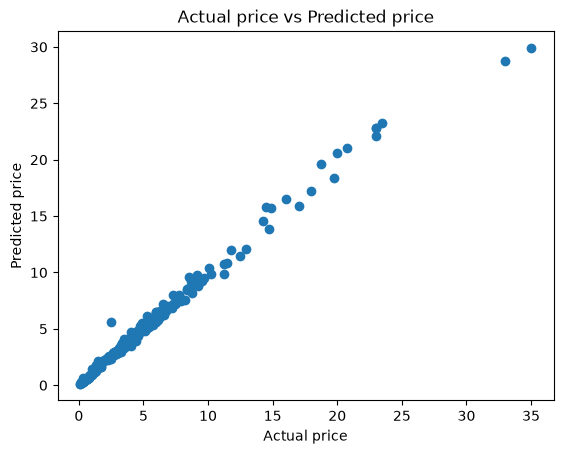

In [259]:
plt.scatter(Y_train,prediction)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual price vs Predicted price")

Prediction on testing data

In [260]:
#prediction on testing data
t_prediction=model.predict(X_test)

In [269]:
# R squared error
error_score_lrtest=metrics.r2_score(Y_test,t_prediction)
print("r2 score",error_score)
mae_lrtest = mean_absolute_error(Y_test,t_prediction)
print("MAE:", mae)
rmse_lrtest = np.sqrt(mean_squared_error(Y_test,t_prediction))
print("RMSE:", rmse)

r2 score 0.988982919072927
MAE: 0.24245481481481493
RMSE: 0.5468745060188244


Text(0.5, 1.0, 'Actual price vs Predicted price')

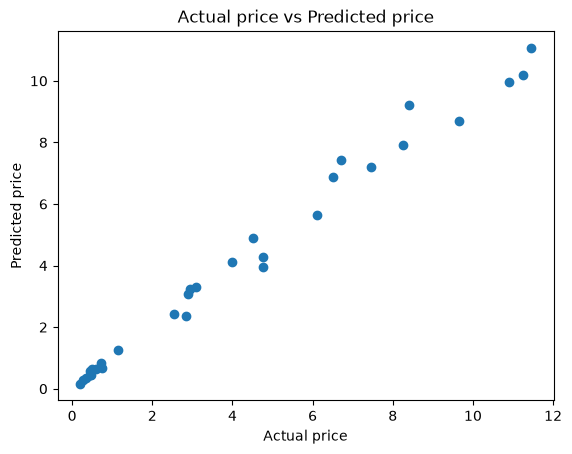

In [270]:
plt.scatter(Y_test,t_prediction)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual price vs Predicted price")

2.Random Forest Regressor

In [236]:
model=RandomForestRegressor()
model.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [237]:
#prediction on training data
prediction=model.predict(X_train)

In [262]:
# R squared error
error_score_rfr=metrics.r2_score(Y_train,prediction)
print("r2 score",error_score)
mae_rfr = mean_absolute_error(Y_train, prediction)
print("MAE:", mae)
rmse_rfr = np.sqrt(mean_squared_error(Y_train, prediction))
print("RMSE:", rmse)

r2 score 0.988982919072927
MAE: 0.24245481481481493
RMSE: 0.5468745060188244


Text(0.5, 1.0, 'Actual price vs Predicted price')

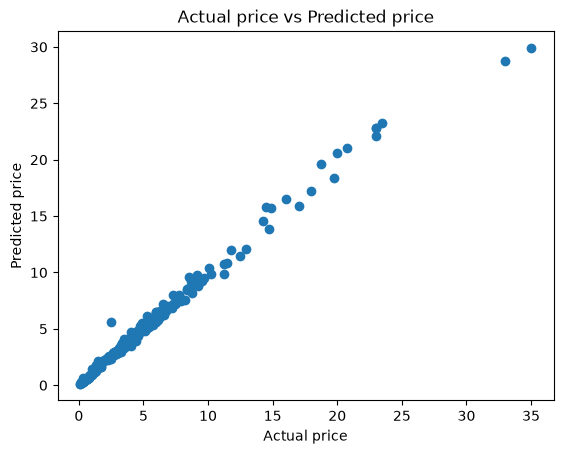

In [239]:
plt.scatter(Y_train,prediction)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual price vs Predicted price")

In [240]:
#prediction on testing data
t_prediction=model.predict(X_test)

In [272]:
# R squared error
error_score_rfrtest=metrics.r2_score(Y_test,t_prediction)
print("r2 score",error_score)
mae_rfrtestt = mean_absolute_error(Y_test,t_prediction)
print("MAE:", mae)
rmse_rfrtest = np.sqrt(mean_squared_error(Y_test,t_prediction))
print("RMSE:", rmse)

r2 score 0.988982919072927
MAE: 0.24245481481481493
RMSE: 0.5468745060188244


Text(0.5, 1.0, 'Actual price vs Predicted price')

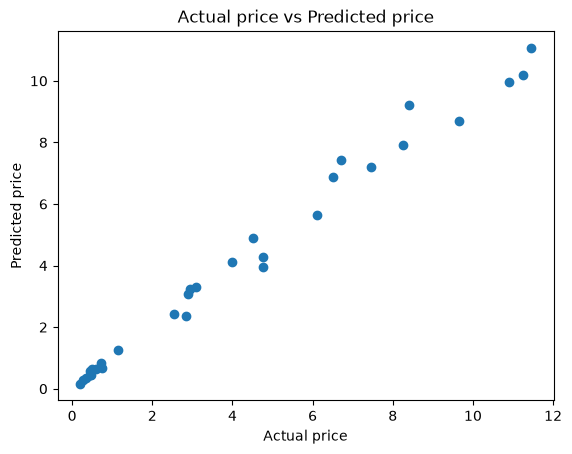

In [273]:
plt.scatter(Y_test,t_prediction)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual price vs Predicted price")

Text(0.5, 1.0, 'Actual price vs Predicted price')

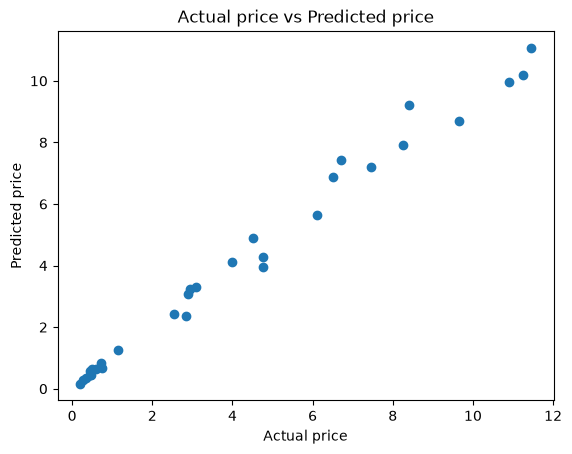

In [274]:
plt.scatter(Y_test,t_prediction)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual price vs Predicted price")

In [276]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    
    "Training MAE": [mae_lr, mae_rfr],
    "Testing MAE": [mae_lrtest, mae_rfrtestt],
    
    "Training RMSE": [rmse_lr, rmse_rfr],
    "Testing RMSE": [rmse_lrtest, rmse_rfrtest],
    
    "Training R2 Score": [error_score_lr, error_score_rfr],
    "Testing R2 Score": [error_score_lrtest, error_score_rfrtest]
})


In [277]:
comparison


,Model,Training MAE,Testing MAE,Training RMSE,Testing RMSE,Training R2 Score,Testing R2 Score
0,Linear Regression,0.242455,0.322419,0.546875,0.449503,0.988983,0.984643
1,Random Forest Regressor,0.242455,0.322419,0.546875,0.449503,0.988983,0.984643


Plots using seaborm

<Axes: xlabel='Selling_Price', ylabel='Count'>

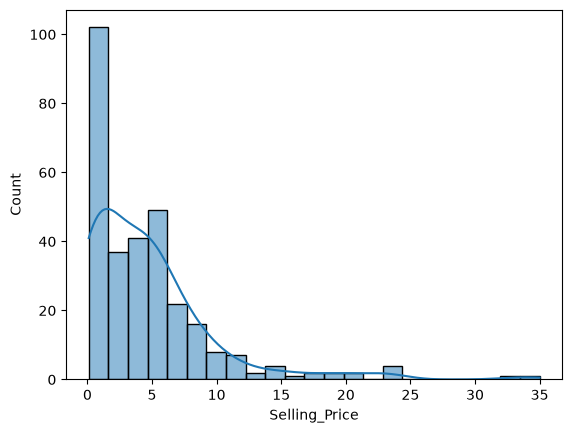

In [243]:
sns.histplot(df["Selling_Price"], kde=True)

<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

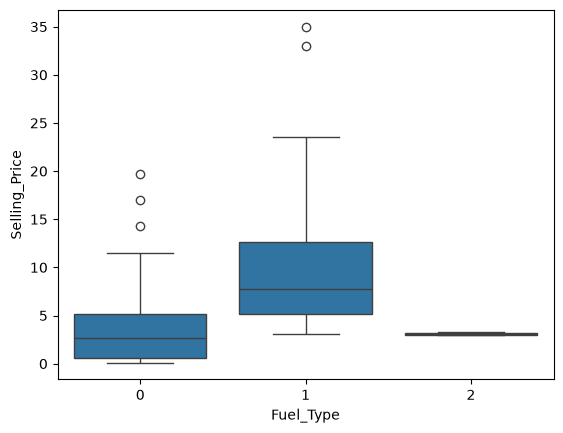

In [244]:
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)

<Axes: xlabel='Car_Age', ylabel='Selling_Price'>

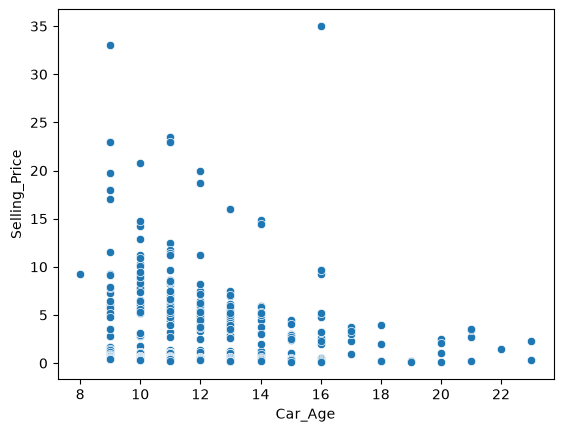

In [245]:
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)

Correlation Heatmap

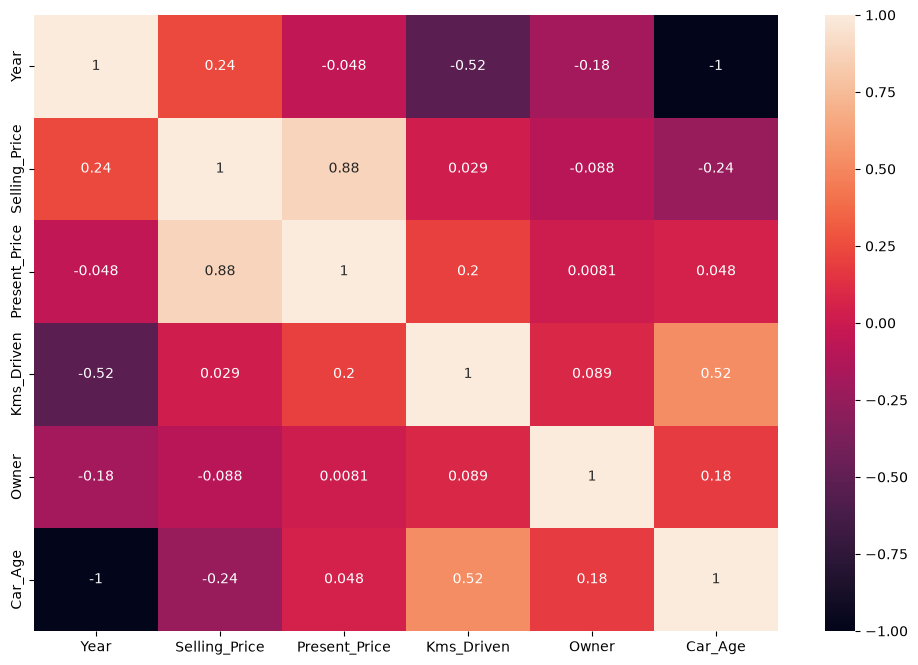

In [246]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()